# From Raw Employee Reviews to Workplace Insight: Cleaning and Analyzing Glassdoor Job Reviews

## Introduction

Employee reviews provide a unique perspective on workplace quality because they combine numeric evaluations with direct written opinions from workers. These reviews can reveal patterns, related to compensation, work-life balance, management quality and overall employee satisfaction. At the same time, data is often inconsistent and noisy, which makes careful preprocessing essential before any meaningful conclusions can be drawn.\
The aim of this project is to transform a large raw Glassdoor dataset into reliable analytical dataset and to investigate which workplace factors are most strongly associated with positive and negative employee evaluations. In addition to exploratory and comparative analysis, the project also emphasizes practical data-science work such as auditing, missing-value treatment, categorical standartization and text-preprocessing.\
To place the findings in broader context, the analysis is supplemented with a second independent source ocntaining macroeconomic indicators. This allows the project to connect individual workspace reviews with wider economic conditions while preserving the main analytical focus on individual employee review data.

## Problem Formulation

### Problem Statement

Online employee reviews provide a valuable but imperfect source of information about workplace quality. They combined structured evaluation metrics such as ratings for work-life balance, compensation and management with unstructured text fields containing personal experience and opinions. This makes them highly informative, but also difficult to analyze directly because the data may contain missing values, inconsistent categories, noisy text, duplicated entries and other quality issues.\
The central problem of this project is how to transform a large raw employee-review dataset into reliable analytical dataset and use it to extraxt meaningful insights about workplace satisfaction and dissatisfaction. The project focuses not only on identifying patterns in employee evaluations, but also on demonstrating a full data science workflow: data auditing, cleaning, preprocessing, exploratory analysis and interpretation.\
More specifically, the analysis aims to examine which workplace factors are more strongly associated with positive and negative overall evaluations, whether current and former employees differs in their assessments and what themes are most common in positive and negative textual feedback. A secondary data source is included to provide more broarder economic context, but the main analytical focus will remain n the Glassdoor review data.

### Research questions

1. What data quality issues are present in Glassdoor employee review dataset and how they can be treated appropriately?
2. Which structured workplace factors are most strongly associated with overall employee ratings?
3. Do current and former employees evaluate their workplaces differently?
4. What are most common themes in positive and negative textual reviews?
5. How can broader economic conditions help contextualise employee perceptions of compensation, benefits and workplace quality?

### Hypotheses

**H1.** Higher ratings for work-life balance, compensation and benefits, career opportunities and senior management are assosiated with higher overall employee ratings.\
**H2.** Former employees tend to leave less favorable reviews than current employees.\
**H3.** Negative textual reviews more frequently emphasize themes related to poor management, heavy workload, limited career growth and dissatisfaction with compensation.\
**H4.** Positive textual reviews more often emphasize flexibility, supportive colleagues, benefits and workplace culture.\
**H5.** Broader iconomic pressure may be reflected in strong dissatisfaction with compensation-related aspects of work, although this relationship should be interpreted as contextual rather than causal.

## Data Sources

This project uses two independent data sources.

The main source is the **Glassdoor Job Reviews** dataset obtained from Kaggle. It contains large number of employee reviews and combines structured evaluation variables with unstructured textual feedback. The structured variables inlcude measures such as overall rating, work-life balance, compensation and benefits, career opportunities, senior management evaluation, recommendation indicators and employment status. In addition, the dataset includes text-free fields such as review headlines, pros and cons. This makes it suitable both for workplace analysis and for demonstrating data-cleaning and preprocessing techniques.\
The second source is macroeconomic dataset obtained from the **World Bank World Development Indicators** database. It includes selected indicators such as inflation, GDP growth and unemployment rates for set of countries in time period 2010-2025. Unlike the Glassdoor dataset, this set is not used for individual-level analysis. Instead, it serves a supporting role by providing broader economic context for the interpretation of employee review patterns.  

### Methodology

The analytical workflow of this project follows the OSEMN framework: obtaining the data, scrubbing and preprocessing it, exploring its structure and patterns, applying analytical methods and intepreting the results. In practice, the methodology is adapted to the specific characteristics of the datasets used in the project.\
The analysis begins with loading the datasets and performing initial inspection in order to understand their structure, variable types and potential data quality issues. This is followed by data-cleaning and preprocessing stage, where missing values, duplicated observations, inconsistent categorical labels and noisy text fields are identified and treated appropriately.\
After the data has been prepared, the project proceeds with exploratory data analysis in order to examine the distribution of key variables and the relationship between key workplace factors and overall employee evaluations. Particular attention is given to current and former employees, as well as to the relationship between structured ratings and text-free feedback.\
The textual fields are then processed separately in order to identify common themes in positive and negative review. Finally, the World Bank dataset is used to provide broader economic context for the interpretation of the review-based findings. The results are discussed with attention to the limitations of the data and the scope of the conclusions that can be reasonably drawn.

### Data Loading and Initial Inspection

The first practical step of the analysis is to load the datasets and inspect their structure, dimensions, variables types and initial data quality characteristics.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [57]:
glassdoor_reviews = pd.read_csv("glassdoor_reviews.csv")

In [58]:
glassdoor_reviews.shape

(838566, 18)

In [59]:
glassdoor_reviews.head(5)

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons
0,AFH-Wealth-Management,2015-04-05,,Current Employee,NaN,2,4.0,3.0,NaN,2.0,3.0,3.0,x,o,r,"Young colleagues, poor micro management",Very friendly and welcoming to new staff. Easy...,"Poor salaries, poor training and communication."
1,AFH-Wealth-Management,2015-12-11,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",2,3.0,1.0,NaN,2.0,1.0,4.0,x,o,r,"Excellent staff, poor salary","Friendly, helpful and hard-working colleagues",Poor salary which doesn't improve much with pr...
2,AFH-Wealth-Management,2016-01-28,Office Administrator,"Current Employee, less than 1 year","Bromsgrove, England, England",1,1.0,1.0,NaN,1.0,1.0,1.0,x,o,x,"Low salary, bad micromanagement",Easy to get the job even without experience in...,"Very low salary, poor working conditions, very..."
3,AFH-Wealth-Management,2016-04-16,,Current Employee,NaN,5,2.0,3.0,NaN,2.0,2.0,3.0,x,o,r,Over promised under delivered,Nice staff to work with,No career progression and salary is poor
4,AFH-Wealth-Management,2016-04-23,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",1,2.0,1.0,NaN,2.0,1.0,1.0,x,o,x,client reporting admin,"Easy to get the job, Nice colleagues.","Abysmal pay, around minimum wage. No actual tr..."


In [60]:
glassdoor_reviews.dtypes

firm                    object
date_review             object
job_title               object
current                 object
location                object
overall_rating           int64
work_life_balance      float64
culture_values         float64
diversity_inclusion    float64
career_opp             float64
comp_benefits          float64
senior_mgmt            float64
recommend               object
ceo_approv              object
outlook                 object
headline                object
pros                    object
cons                    object
dtype: object

The initial inspection shows that the dataset contains both structured and unstructured variables. At this stage, main goal is to identify potential data quality issues such as missing values, duplicated observations, inconsistent formats and variables that may require type conversion.

In [61]:
glassdoor_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838566 entries, 0 to 838565
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   firm                 838566 non-null  object 
 1   date_review          838566 non-null  object 
 2   job_title            838566 non-null  object 
 3   current              838566 non-null  object 
 4   location             541223 non-null  object 
 5   overall_rating       838566 non-null  int64  
 6   work_life_balance    688672 non-null  float64
 7   culture_values       647193 non-null  float64
 8   diversity_inclusion  136066 non-null  float64
 9   career_opp           691065 non-null  float64
 10  comp_benefits        688484 non-null  float64
 11  senior_mgmt          682690 non-null  float64
 12  recommend            838566 non-null  object 
 13  ceo_approv           838566 non-null  object 
 14  outlook              838566 non-null  object 
 15  headline         

In [62]:
glassdoor_reviews.isna().sum().sort_values(ascending=False)

diversity_inclusion    702500
location               297343
culture_values         191373
senior_mgmt            155876
comp_benefits          150082
work_life_balance      149894
career_opp             147501
headline                 2590
cons                       13
pros                        2
date_review                 0
overall_rating              0
current                     0
recommend                   0
ceo_approv                  0
outlook                     0
job_title                   0
firm                        0
dtype: int64

The initial inspection shows that several columns contain substantial missingness. While some variables such as firm, job_title, outlook, date_review, overall_rating, etc. appear complete, others, including diversity_inclusion and location, contain large number of missing values and will require careful treatment.

In [63]:
glassdoor_reviews.duplicated().sum()

np.int64(33515)

In [64]:
glassdoor_reviews.nunique().sort_values()

recommend                   3
outlook                     4
ceo_approv                  4
diversity_inclusion         5
overall_rating              5
work_life_balance           5
culture_values              5
senior_mgmt                 5
career_opp                  5
comp_benefits               5
current                    29
firm                      428
date_review              4813
location                14486
job_title               62275
headline               390454
cons                   777133
pros                   778559
dtype: int64

### Recoding Categorical Variables

In [65]:
for col in ['current', 'recommend', 'ceo_approv', 'outlook']:
    print(f"\nColumn: {col}")
    print(glassdoor_reviews[col].value_counts(dropna=False))


Column: current
current
Current Employee                           209599
Former Employee                            146133
Current Employee, more than 1 year          82749
Current Employee, more than 3 years         66471
Former Employee, more than 1 year           65687
Current Employee, less than 1 year          49603
Former Employee, more than 3 years          43614
Former Employee, less than 1 year           41874
Current Employee, more than 5 years         40155
Current Employee, more than 10 years        25029
Former Employee, more than 5 years          23017
Current Employee, more than 8 years         18506
Former Employee, more than 10 years         15411
Former Employee, more than 8 years          10686
Former Contractor, less than 1 year             6
Former Intern, less than 1 year                 5
Current Contractor, less than 1 year            3
Current Contractor, more than 1 year            3
Former Contractor                               2
Current Contractor       

The columns **recommend**, **ceo_approv** and **outlook** are encoded categorical variables representing employee endorsment, CEO approval and business outlook. According to the dataset description in Kaggle, the encoded values correspond for **v - Positive, r - Mild, x - Negative and o - No opinion.** This categories needs to be encoded into readable categories before further analysis.

In [66]:
glassdoor_reviews['recommend'] = glassdoor_reviews['recommend'].replace({
    'v':'Positive',
    'o':'No opinion',
    'x':'Negative'})

In [67]:
glassdoor_reviews['ceo_approv'] = glassdoor_reviews['ceo_approv'].replace({
    'v':'Positive',
    'r':'Mild',
    'o':'No opinion',
    'x':'Negative'})

In [68]:
glassdoor_reviews['outlook'] = glassdoor_reviews['outlook'].replace({
    'v':'Positive',
    'r':'Mild',
    'o':'No opinion',
    'x':'Negative'})

The original current column contains multiple variants combining employment status and tenure information. To improve interpretability, a new variable called employee_status was created with three categories: Current, Former, and Other. The recoding shows that almost all observations fall into the first two categories, while only a small number of records remain classified as Other.

In [69]:
glassdoor_reviews['employee_status'] = np.where(glassdoor_reviews['current'].str.contains('Current', na = False), 'Current', np.where(glassdoor_reviews['current'].str.contains('Former', na = False), 'Former', 'Other'))

In [70]:
glassdoor_reviews[glassdoor_reviews['employee_status']=='Other']

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons,employee_status
787336,UHMBT,2020-11-17,MLA,KEY NOT FOUND: jobLine.per_diem-former,"Lancaster, England, England",4,3.0,4.0,4.0,2.0,3.0,4.0,Positive,Mild,Positive,"fair employer, very good working condition","fair employer, very good working condition",hard to move on with your career,Other
826279,Western-Health-and-Social-Care-Trust,2020-05-23,Registered Nurse,KEY NOT FOUND: jobLine.per_diem-former,"Omagh, Northern Ireland, Northern Ireland",5,NaN,NaN,NaN,NaN,NaN,NaN,No opinion,No opinion,No opinion,Good to staff,Good experience as a staff nurse,Took a while to solve issues,Other
826282,Western-Health-and-Social-Care-Trust,2020-10-04,Sales Assistant,KEY NOT FOUND: jobLine.temporary-former,"Derry, Northern Ireland, Northern Ireland",3,3.0,3.0,3.0,4.0,3.0,3.0,Positive,Positive,Positive,Good job,Helping people with my degree,Contract was only temporary so I had to be let go,Other


Inspection of the smal number observations, initially classified as 'Other' showed that they are not substantially different employee categories, but rather malformed text values containing strings such as "KEY NOT FOUND" together with reference to former employment. Since these recordings are only 3 and clearly indicate for e former employee, they will be recorded accordingly. This will reduce noise and improve consistency of the new variable employee_status.

In [71]:
glassdoor_reviews['employee_status'] = np.where(glassdoor_reviews['current'].str.contains('Current',case = False, na = False), 'Current', np.where(glassdoor_reviews['current'].str.contains('Former',case = False, na = False), 'Former', 'Other'))

In [72]:
glassdoor_reviews.employee_status.value_counts()

employee_status
Current    492122
Former     346444
Name: count, dtype: int64

### Date Conversion

In [73]:
glassdoor_reviews.date_review.value_counts()

date_review
2021-01-13    1761
2021-01-11    1713
2021-01-12    1629
2021-01-19    1613
2021-01-14    1581
              ... 
2008-03-24       1
2008-02-05       1
2008-02-11       1
2008-03-04       1
2021-06-08       1
Name: count, Length: 4813, dtype: int64

In [74]:
glassdoor_reviews['date_review'] = pd.to_datetime(glassdoor_reviews['date_review'], errors = 'coerce')

In [75]:
glassdoor_reviews['date_review'].dtype

dtype('<M8[ns]')

In [76]:
glassdoor_reviews['date_review'].isna().sum()

np.int64(0)

In [77]:
glassdoor_reviews['review_year'] = glassdoor_reviews['date_review'].dt.year
glassdoor_reviews['review_month'] = glassdoor_reviews['date_review'].dt.month

In [78]:
glassdoor_reviews.review_year.value_counts().sort_index()

review_year
2008      5693
2009      5958
2010     10110
2011     10886
2012     20587
2013     24696
2014     39505
2015     69241
2016     84427
2017     91333
2018     87954
2019    103288
2020    140310
2021    144578
Name: count, dtype: int64

In [79]:
glassdoor_reviews.review_month.value_counts().sort_index()

review_month
1     86679
2     79241
3     81971
4     73400
5     75960
6     57944
7     56055
8     65716
9     68937
10    75456
11    62186
12    55021
Name: count, dtype: int64

The **date_review** column was converted from object type to datetimeformat in order to support time-based analysis. The conversion allows extraction to additional variables such as review_year and review_month, which can be used later to examine temporal patterns in employee reviews. 

### Duplicates

In [80]:
glassdoor_reviews[glassdoor_reviews.duplicated()].shape

(33515, 21)

In [81]:
duplicates = glassdoor_reviews.duplicated(keep=False)
glassdoor_reviews[duplicates].sort_values(by=['firm', 'date_review', 'job_title']).head(10)

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,...,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons,employee_status,review_year,review_month
1231,ASDA,2010-10-29,Asda Manager,Former Employee,NaN,5,5.0,NaN,NaN,5.0,...,4.0,Positive,No opinion,No opinion,bil,"great team work, working together",long hours long shift patterns,Former,2010,10
1232,ASDA,2010-10-29,Asda Manager,Former Employee,NaN,5,5.0,NaN,NaN,5.0,...,4.0,Positive,No opinion,No opinion,bil,"great team work, working together",long hours long shift patterns,Former,2010,10
1271,ASDA,2013-04-24,Shop Floor Assistant,"Current Employee, more than 1 year",NaN,4,2.0,4.0,NaN,3.0,...,3.0,Positive,Positive,Positive,"Good company to work for, very customer experi...",10% discount on shopping in store and online\r...,Always short staffed with huge targets to hit\...,Current,2013,4
1272,ASDA,2013-04-24,Shop Floor Assistant,"Current Employee, more than 1 year",NaN,4,2.0,4.0,NaN,3.0,...,3.0,Positive,Positive,Positive,"Good company to work for, very customer experi...",10% discount on shopping in store and online\r...,Always short staffed with huge targets to hit\...,Current,2013,4
1291,ASDA,2013-11-20,Picker,"Current Employee, more than 1 year","London, England, England",3,3.0,3.0,NaN,3.0,...,2.0,Negative,Mild,Mild,"Long hours, okay pay, hard work, difficult man...","Flexible hours, people are friendly, shop disc...","Management can be difficult to work with, pres...",Current,2013,11
1292,ASDA,2013-11-20,Picker,"Current Employee, more than 1 year","London, England, England",3,3.0,3.0,NaN,3.0,...,2.0,Negative,Mild,Mild,"Long hours, okay pay, hard work, difficult man...","Flexible hours, people are friendly, shop disc...","Management can be difficult to work with, pres...",Current,2013,11
1337,ASDA,2014-05-24,Shop Floor Assistant (Nights),"Current Employee, more than 8 years","Hinckley, England, England",3,2.0,2.0,NaN,3.0,...,3.0,Negative,Mild,Mild,A brief summary of a near 10 year nightshift c...,Friendly colleagues make for a pleasant and re...,Financial constraints and reduction in employe...,Current,2014,5
1338,ASDA,2014-05-24,Shop Floor Assistant (Nights),"Current Employee, more than 8 years","Hinckley, England, England",3,2.0,2.0,NaN,3.0,...,3.0,Negative,Mild,Mild,A brief summary of a near 10 year nightshift c...,Friendly colleagues make for a pleasant and re...,Financial constraints and reduction in employe...,Current,2014,5
1399,ASDA,2014-06-16,Designer,"Former Employee, less than 1 year","Leeds, England, England",1,2.0,1.0,NaN,1.0,...,1.0,Negative,Positive,Mild,"team work is unheard of, you're on your own",I learnt a lot of things there. self time mana...,managment rarely around. I was without a manag...,Former,2014,6
1400,ASDA,2014-06-16,Designer,"Former Employee, less than 1 year","Leeds, England, England",1,2.0,1.0,NaN,1.0,...,1.0,Negative,Positive,Mild,"team work is unheard of, you're on your own",I learnt a lot of things there. self time mana...,managment rarely around. I was without a manag...,Former,2014,6


In [82]:
glassdoor_reviews = glassdoor_reviews.drop_duplicates()
glassdoor_reviews.shape

(805051, 21)

Inspection of duplicated records showed that duplicated() identifies repeated occurrences rather than displaying the original matching row by default. After reviewing duplicate groups, exact duplicate observations were removed to reduce redundancy in the dataset.

### Missing Values 

The next step in the preprocessing stage is to evaluate the extent of missing data across the dataset. This is important because missingness is not distributed uniformly across variables. Some columns are nearly complete, while others contain a substantial proportion of missing values and may require special treatment, limited use or exclusion from certain part of the analysis.

In [83]:
missing_summary = pd.DataFrame({'missing_count': glassdoor_reviews.isna().sum(),
                                'missing_percentage': glassdoor_reviews.isna().sum()/len(glassdoor_reviews)*100}).sort_values(by='missing_percentage', ascending = False)

missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_percentage
diversity_inclusion,674160,83.741279
location,285095,35.413284
culture_values,183364,22.776694
senior_mgmt,149804,18.608014
comp_benefits,144242,17.917126
work_life_balance,144060,17.894518
career_opp,141726,17.604599
headline,2451,0.304453
cons,13,0.001615
pros,2,0.000248


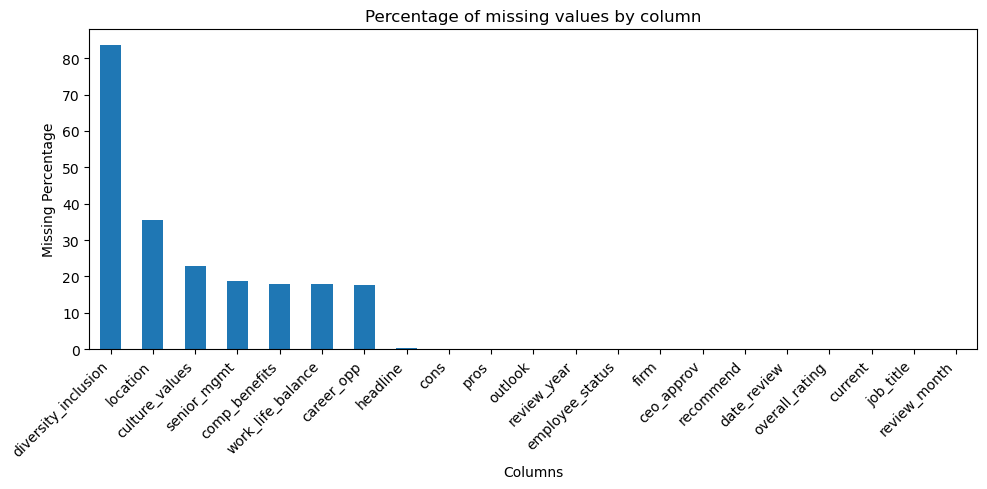

In [84]:
plt.figure(figsize = (10, 5))
missing_summary['missing_percentage'].plot(kind = 'bar')
plt.title('Percentage of missing values by column')
plt.xlabel('Columns')
plt.ylabel('Missing Percentage')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

The missing-value summary confirms that missingness is concentrated in a limited number of variables. In particular, **diversity_inclusion** contains a very high proportion of missing values, while **location** also shows substantial missingness. By contrast, the core rating variables and the main text fields are relatively complete. These results suggest that the missing-value treatment should be performed selectively rather than uniformly accross all columns.

#### Missing Value Treatment Decisions

##### Diversity Inclusion

In [85]:
glassdoor_reviews['diversity_inclusion'].isna().sum()

np.int64(674160)

In [86]:
glassdoor_reviews['diversity_inclusion'].value_counts(dropna=False).sort_index()

diversity_inclusion
1.0      8194
2.0      8223
3.0     21760
4.0     34606
5.0     58108
NaN    674160
Name: count, dtype: int64

In [87]:
glassdoor_reviews['diversity_inclusion'].describe().T

count    130891.000000
mean          3.964245
std           1.193159
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: diversity_inclusion, dtype: float64

In [88]:
glassdoor_reviews.groupby(glassdoor_reviews['diversity_inclusion'].isna())['overall_rating'].agg(['count', 'mean', 'median'])

,count,mean,median
diversity_inclusion,,,
False,130891,3.820118,4.0
True,674160,3.625243,4.0


In [89]:
pd.crosstab(glassdoor_reviews['employee_status'],
            glassdoor_reviews['diversity_inclusion'].isna(), normalize = 'index')

diversity_inclusion,False,True
employee_status,,
Current,0.164578,0.835422
Former,0.159778,0.840222


In [90]:
pd.crosstab(glassdoor_reviews['review_year'],
            glassdoor_reviews['diversity_inclusion'].isna())

diversity_inclusion,False,True
review_year,,
2008,0,5351
2009,0,5671
2010,0,9528
2011,0,10328
2012,0,19500
2013,0,23582
2014,0,37883
2015,0,66393
2016,0,80977


In [91]:
diversity_2020 = glassdoor_reviews[glassdoor_reviews['review_year']==2020].copy()
pd.crosstab(diversity_2020['review_month'], diversity_2020['diversity_inclusion'].isna())

diversity_inclusion,False,True
review_month,,
1,0,8527
2,0,8168
3,0,6152
4,0,5788
5,0,6893
6,0,7891
7,0,8102
8,4,14808
9,1372,15597


In [92]:
diversity_2021 = glassdoor_reviews[glassdoor_reviews['review_year']==2021].copy()
pd.crosstab(diversity_2021['review_month'], diversity_2021['diversity_inclusion'].isna())

diversity_inclusion,False,True
review_month,,
1,21412,10500
2,19772,8063
3,20304,8658
4,17082,7712
5,15448,7186
6,1911,967


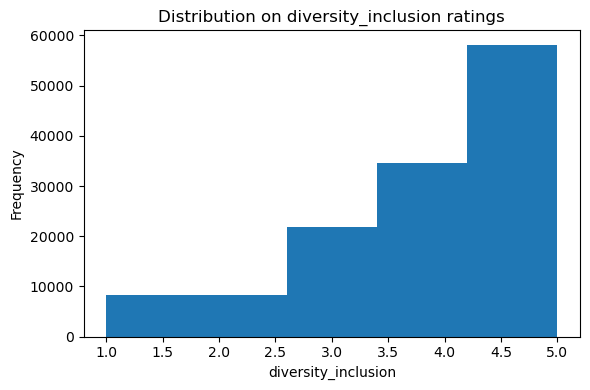

In [93]:
plt.figure(figsize = (6,4))
glassdoor_reviews['diversity_inclusion'].dropna().plot(kind = 'hist', bins = 5)
plt.title('Distribution on diversity_inclusion ratings')
plt.xlabel('diversity_inclusion')
plt.tight_layout()
plt.show()

The analysis of **diversity_inclusion** shows that this variable contains a very high proportion of missing values, with approximately 84% of observation lacking a recorded rating. Among the available values, the distribution is concentrated towards the upper end of the scale, with ratings of 4 and 5 being the most common. The descriptive statistics also indicate a relatively positive distribution with mean 3.96 and median 4.\
Further inspection suggest that the missingness is not random. Cross-tabulation by review year shows that the variable is entirely missing in earlier years and begins to appear only in more recent observations(2020 and 2021), which indicates that this rating was most likely introduced later. More detailed monthly analysis for 2020 and 2021 shows that the variable is available from August 2020 until June 2021. In August 2020 we have only 4 observations, after that non-missing values begin to increase noticeably in September and become much more common from October onward. By contrast, missingness does not differ substantially between current and former employees.\
Because of its very high and structually patterned missingness, **diversity_inclusion** is not suitable for use as a core variable in the main analysis. However, the available non-missing values may still be used for limited supplementary interpretation treated with caution.

##### Location

In [94]:
glassdoor_reviews['location'].isna().sum()

np.int64(285095)

In [95]:
glassdoor_reviews['location'].isna().sum()/len(glassdoor_reviews['location']) * 100

np.float64(35.41328437577247)

In [96]:
glassdoor_reviews['location'].value_counts(dropna=False)

location
NaN                                 285095
London, England, England             57341
New York, NY                         30090
Bangalore                            25672
Hyderābād                            10603
                                     ...  
Honiara                                  1
Aghia Paraskevi                          1
Kishangarh, Rajasthan, Rajasthan         1
Kampung Joh                              1
Wijnegem, Antwerp                        1
Name: count, Length: 14487, dtype: int64

In [97]:
glassdoor_reviews['location'].value_counts(dropna=False).head(20)

location
NaN                             285095
London, England, England         57341
New York, NY                     30090
Bangalore                        25672
Hyderābād                        10603
Mumbai                            9120
Gurgaon, Haryana, Haryana         8059
Chicago, IL                       7512
Singapore                         7266
San Francisco, CA                 7046
Dublin, Dublin                    6997
Redmond, WA                       6807
Pune                              6390
Toronto, ON                       6381
Manchester, England, England      5539
Dallas, TX                        4551
Sydney                            4530
Los Angeles, CA                   4167
Boston, MA                        4131
Birmingham, England, England      4076
Name: count, dtype: int64

In [98]:
glassdoor_reviews['location'].describe()

count                       519956
unique                       14486
top       London, England, England
freq                         57341
Name: location, dtype: object

In [99]:
pd.crosstab(glassdoor_reviews['review_year'],
            glassdoor_reviews['location'].isna(), normalize='index').round(3)

location,False,True
review_year,,
2008,0.932,0.068
2009,0.721,0.279
2010,0.628,0.372
2011,0.605,0.395
2012,0.684,0.316
2013,0.696,0.304
2014,0.663,0.337
2015,0.607,0.393
2016,0.593,0.407


In [ ]:
pd.crosstab(glassdoor_reviews['employee_status'], 
            glassdoor_reviews['location'].isna(), normalize = 'index').round(3)

In [103]:
glassdoor_reviews['location'].dropna().sample(20, random_state = 23).to_list()

['Palo Alto, CA',
 'Columbia, SC',
 'Walker, LA',
 'Indi, Karnataka, Karnataka',
 'Westford, MA',
 'Taipei',
 'New York, NY',
 'Swindon, Wiltshire, South West England, England, England',
 'Hyderābād',
 'Hyderābād',
 'London, England, England',
 'Boston, MA',
 'Seattle, WA',
 'The Colony, TX',
 'Athens',
 'Boston, MA',
 'Pune',
 'Bangalore',
 'Singapore',
 'New York, NY']

The analysis of **location** variable shows that it contains substanstial missingness with approximately 35.4% of values absent, as well as high cardinality with 14486 unique non-missing entires. Missingness is not constant over time, which suggests differences in data completeness across review years. At the same time, the non-missing values clearly contain meaningful geographic information. However, the formatting is highly inconsistent, with some entries recorded as cities, others as city-state pairs, and others as longer multi-level strings. For this reason, the raw **location** field is not suitable for direct use in the main analysis and should instead be treated as a candidate for simplified feature engineering, such as deriving an estimated country or restricting analysis to the most frequent locations.

In [104]:
glassdoor_reviews['location'].dropna().str.count(',').value_counts().sort_index()

location
0    133172
1    215471
2    161317
3      8260
4      1733
5         3
Name: count, dtype: int64

In [112]:
glassdoor_reviews['estimated_country']=glassdoor_reviews['location'].str.split(',').str[-1].str.strip()

In [113]:
glassdoor_reviews['estimated_country'].value_counts().head(20)

estimated_country
England      134416
NY            35052
CA            30535
Bangalore     25672
TX            15876
WA            12037
Hyderābād     10603
Scotland      10249
IL             9835
ON             9764
Mumbai         9120
FL             8882
Haryana        8081
Singapore      7266
Dublin         7052
MA             6409
Pune           6390
GA             5515
PA             5447
MI             4767
Name: count, dtype: int64

In [115]:
glassdoor_reviews = glassdoor_reviews.rename(columns = {'estimated_county':'location_last_part'})

The **location** variable contains potentially valuable geographic information, but its inconsistent formatting prevents straightforward use in the current preprocessing stage. A more refined geographic standartization may be considered later in the project as an optimal feauture-engineering step.